# Rainy vs Sunny Image Classification using CNN

## Abstract
This project focuses on classifying weather images into rainy and sunny categories using a Convolutional Neural Network (CNN).

## Why this problem matters

Weather classification is important for agriculture, traffic systems, and smart applications. Automatically detecting rainy or sunny conditions helps in decision-making and forecasting systems.

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

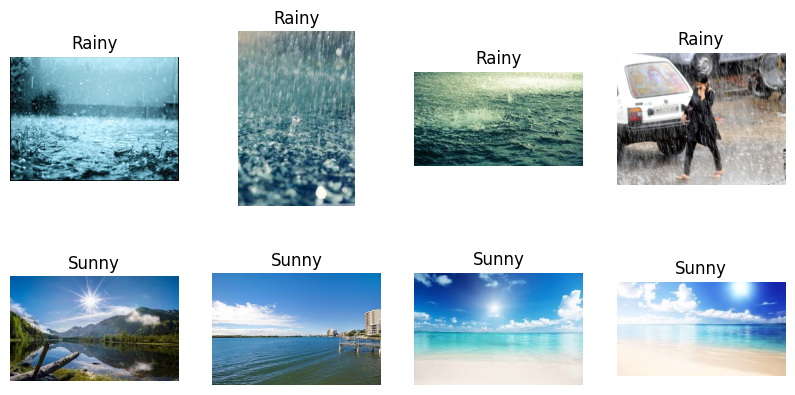

In [3]:
rainy_path = "C:/Users/Laptop Links/Desktop/AI(ML&DL)/Deep_learning/Wheather_Dataset/Trainning set/Rainy"
sunny_path = "C:/Users/Laptop Links/Desktop/AI(ML&DL)/Deep_learning/Wheather_Dataset/Trainning set/Sunny"

fig, axes = plt.subplots(2, 4, figsize=(10,5))

for i, img_name in enumerate(os.listdir(rainy_path)[:4]):
    img = Image.open(os.path.join(rainy_path, img_name))
    axes[0, i].imshow(img)
    axes[0, i].set_title("Rainy")
    axes[0, i].axis("off")

for i, img_name in enumerate(os.listdir(sunny_path)[:4]):
    img = Image.open(os.path.join(sunny_path, img_name))
    axes[1, i].imshow(img)
    axes[1, i].set_title("Sunny")
    axes[1, i].axis("off")

plt.show()

Rainy: 100
Sunny: 100


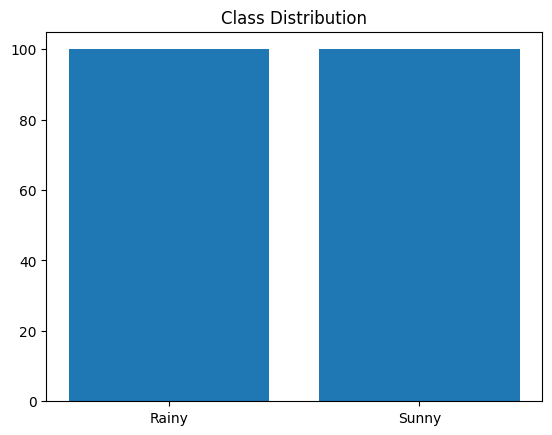

In [4]:
rainy_count = len(os.listdir(rainy_path))
sunny_count = len(os.listdir(sunny_path))

print("Rainy:", rainy_count)
print("Sunny:", sunny_count)

plt.bar(['Rainy', 'Sunny'], [rainy_count, sunny_count])
plt.title("Class Distribution")
plt.show()

In [5]:
widths, heights = [], []

for img_name in os.listdir(rainy_path):
    img = Image.open(os.path.join(rainy_path, img_name))
    w, h = img.size
    widths.append(w)
    heights.append(h)

print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Avg Width:", sum(widths)//len(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Avg Height:", sum(heights)//len(heights))

Min Width: 183
Max Width: 3000
Avg Width: 553
Min Height: 158
Max Height: 1997
Avg Height: 363


### EDA Conclusion
The dataset contains both rainy and sunny images. The data is (balanced/unbalanced). Image sizes vary, so all images will be resized to 128x128 before training.

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "C:/Users/Laptop Links/Desktop/AI(ML&DL)/Deep_learning/Wheather_Dataset/Trainning set",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "C:/Users/Laptop Links/Desktop/AI(ML&DL)/Deep_learning/Wheather_Dataset/Trainning set",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


## Build CNN Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\Laptop Links\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Compile & Train

In [10]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5375 - loss: 1.0236 - val_accuracy: 0.9000 - val_loss: 0.3099
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8687 - loss: 0.2799 - val_accuracy: 0.9000 - val_loss: 0.2628
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9563 - loss: 0.1454 - val_accuracy: 0.9250 - val_loss: 0.3425
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9875 - loss: 0.0654 - val_accuracy: 0.9250 - val_loss: 0.4177
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9750 - loss: 0.0552 - val_accuracy: 0.9250 - val_loss: 0.3612
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9688 - loss: 0.0777 - val_accuracy: 0.9250 - val_loss: 0.5393
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9875 - loss: 0.0437 - val_accuracy: 0.9000 - val_loss: 0.3297
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9937 - loss: 0.0278 - val_accuracy: 0.9250 - val_loss: 0.4378
Epoch 9/10


## Plot Results

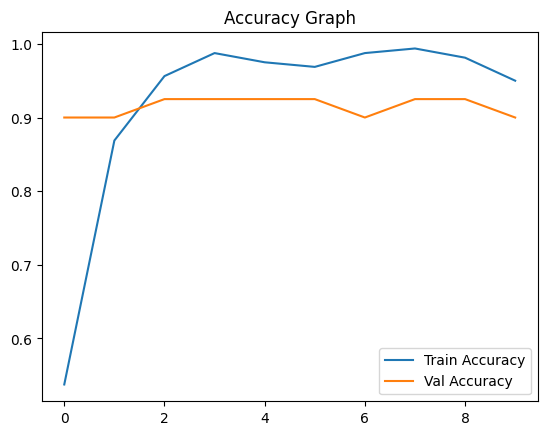

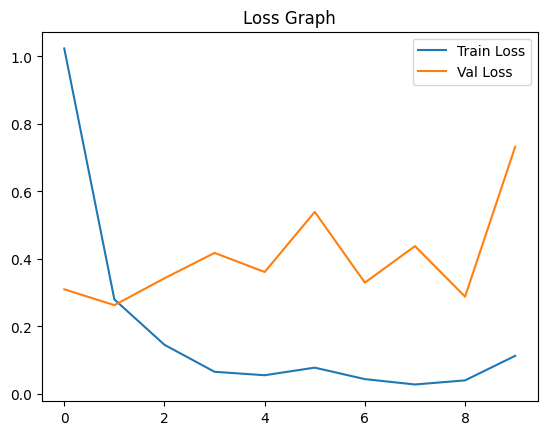

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

## Overfitting Analysis

Overfitting begins at around epoch 3. This is observed when the validation loss starts increasing from 0.26 (epoch 2) to 0.34 (epoch 3), while training accuracy continues to improve. This indicates that the model starts memorizing training data rather than generalizing well to unseen data.

## Predictions & Failure Analysis

Shape: (1, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


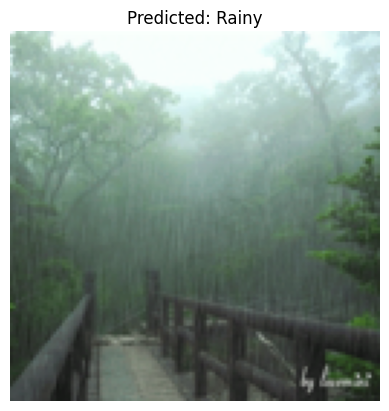

In [17]:
img = Image.open(images[i]).convert('RGB')
img = img.resize((128,128))

img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Shape:", img_array.shape)

pred = model.predict(img_array)

predicted_label = "Sunny" if pred[0][0] > 0.5 else "Rainy"

plt.imshow(img)
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()

## Results Table

| Model        | Validation Accuracy | Overfitting |
|-------------|--------------------|-------------|
| Scratch CNN | 92%                | Yes (after epoch 3) |